# MQDT Spectrum with overlaps of OSQDT states and Tunable MQDT models

This notebook compares the OSQDT channel spectra with the full MQDT spectrum and illustrates how the levels evolve as the tunable MQDT coupling factor increases from 0 to 1. Levels are plotted against the effective principal quantum number $\nu$, and the colored segments of each full MQDT level show its summed squared overlaps with the different OSQDT channel groups.

The plots, including the spectra obtained by tuning the coupling, are intended only as didactic examples to illustrate channel mixing. Only the full MQDT results should be used for calculations.

In [1]:
from __future__ import annotations

# %matplotlib widget
import logging

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection
from utils import build_segments

logging.basicConfig(level=logging.INFO)
logging.getLogger("matplotlib").setLevel(logging.WARNING)
logging.getLogger("rydstate").setLevel(logging.WARNING)

In [2]:
from typing import TYPE_CHECKING

import rydstate

if TYPE_CHECKING:
    from rydstate.rydberg_state import RydbergState

In [ ]:
species = "Yb171"
l_r = 0
f_tot = 0.5
nu_range = (0, 150)

basis_osqdt = rydstate.basis.BasisOSQDT(species, nu=nu_range, l_r=(l_r, l_r + 1), f_tot=(f_tot, f_tot))
basis_mqdt = rydstate.BasisMQDT(species, nu=nu_range, l_r=(l_r, l_r), f_tot=(f_tot, f_tot))

In [ ]:
coupling_factors = np.linspace(0, 1, 10)
bases_tunable_mqdt = [
    rydstate.basis.BasisTunableMQDT(species, nu=nu_range, l_r=(l_r, l_r), f_tot=(f_tot, f_tot), coupling_factor=c)
    for c in coupling_factors
]

In [5]:
basis_dict: dict[str, rydstate.basis.BasisBase[RydbergState]] = {}

basis_dict["fc=0"] = (
    basis_osqdt.shallow_copy().filter_states("l_c", 0).filter_states("l_r", l_r).filter_states("f_c", 0)
)

basis_dict["fc=1"] = (
    basis_osqdt.shallow_copy().filter_states("l_c", 0).filter_states("l_r", l_r).filter_states("f_c", 1)
)

basis_dict["lc=1 jc=1/2"] = (
    basis_osqdt.shallow_copy().filter_states("l_r", 1).filter_states("l_c", 1).filter_states("j_c", 1 / 2)
)

basis_dict["lc=1 jc=3/2"] = (
    basis_osqdt.shallow_copy().filter_states("l_r", 1).filter_states("l_c", 1).filter_states("j_c", 3 / 2)
)

for key in ["4f13 5d 6snl a", "4f13 5d 6snl b", "4f13 5d 6snl c"]:
    basis_dict[key] = basis_osqdt.shallow_copy().filter_states("parity", +1).filter_states_label(key)


basis_dict["full MQDT"] = basis_mqdt

for key, basis in basis_dict.items():
    print(f"{key}: {len(basis.states)} states")
    for i, state in enumerate(basis.states):
        if i >= 3:
            print("  ...\n")
            break
        print(f"  {state}")

fc=0: 155 states
  |Yb171:(6s_1/2,7s_1/2),f_c=0,F=1/2⟩
  |Yb171:(6s_1/2,8s_1/2),f_c=0,F=1/2⟩
  |Yb171:(6s_1/2,9s_1/2),f_c=0,F=1/2⟩
  ...

fc=1: 148 states
  |Yb171:(6s_1/2,7s_1/2),f_c=1,F=1/2⟩
  |Yb171:(6s_1/2,8s_1/2),f_c=1,F=1/2⟩
  |Yb171:(6s_1/2,9s_1/2),f_c=1,F=1/2⟩
  ...

lc=1 jc=1/2: 2 states
  |Yb171:(6p_1/2,6p_1/2),f_c=0,F=1/2⟩
  |Yb171:(6p_1/2,6p_1/2),f_c=1,F=1/2⟩
lc=1 jc=3/2: 2 states
  |Yb171:(6p_3/2,6p_3/2),f_c=1,F=1/2⟩
  |Yb171:(6p_3/2,6p_3/2),f_c=2,F=1/2⟩
4f13 5d 6snl a: 1 states
  |Yb171:nu=1.8,4f13 5d 6snl a,F=1/2⟩
4f13 5d 6snl b: 1 states
  |Yb171:nu=1.7,4f13 5d 6snl b,F=1/2⟩
4f13 5d 6snl c: 0 states
full MQDT: 307 states
  0.87*|Yb171:(6s_1/2,[2.5]s_1/2),f_c=0,F=1/2⟩ + 3.7e-06*|Yb171:nu=1.5,4f13 5d 6snl a,F=1/2⟩ - 5.7e-06*|Yb171:(6p_3/2,[1.5]p_3/2),f_c=1,F=1/2⟩ + 7.3e-06*|Yb171:(6p_3/2,[1.5]p_3/2),f_c=2,F=1/2⟩ + 1.5e-06*|Yb171:nu=1.5,4f13 5d 6snl b,F=1/2⟩ - 4.6e-06*|Yb171:(6p_1/2,[1.6]p_1/2),f_c=0,F=1/2⟩ + 7.9e-06*|Yb171:(6p_1/2,[1.6]p_1/2),f_c=1,F=1/2⟩ + 4.9e-06*|Yb171

In [6]:
overlaps_dict: dict[str, list[float]] = {}

for key, basis in basis_dict.items():
    if isinstance(basis, rydstate.basis.BasisMQDT):
        continue

    overlaps = basis_mqdt.calc_reduced_overlaps(basis)
    overlaps_dict[key] = np.sum(overlaps**2, axis=1).tolist()

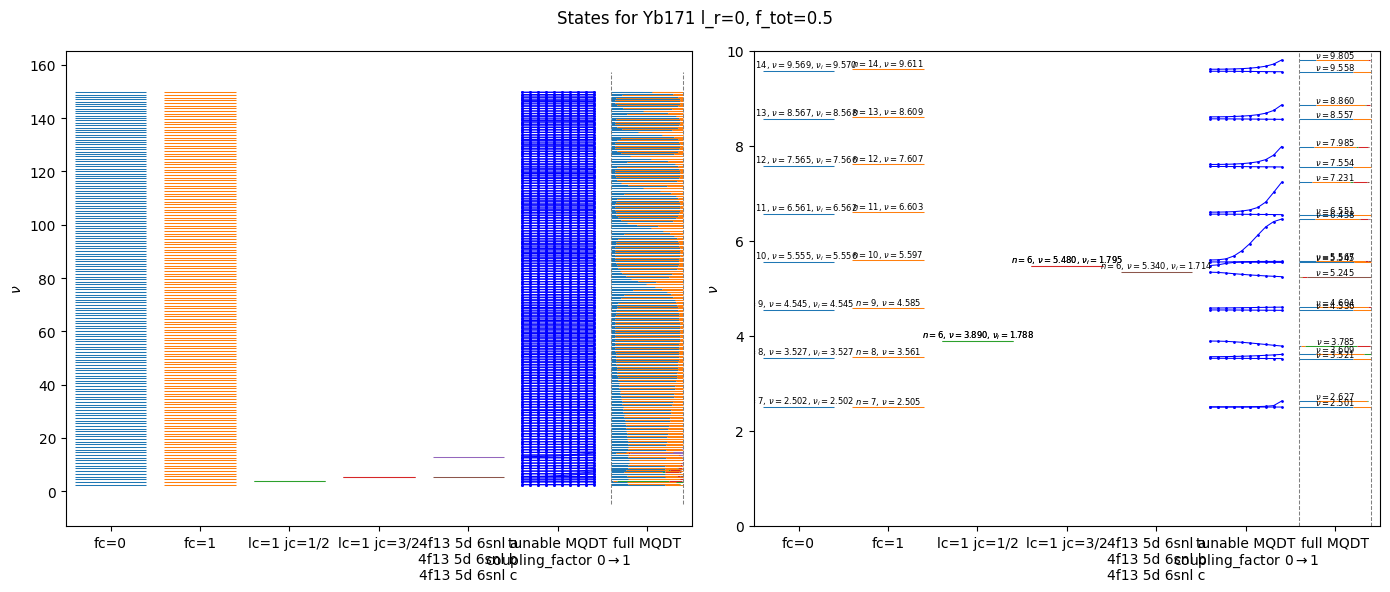

In [ ]:
x_loc = {
    # S_05
    "fc=0": 0,
    "fc=1": 1,
    "lc=1 jc=1/2": 2,
    "lc=1 jc=3/2": 3,
    # general
    "4f13 5d 6snl a": 4,
    "4f13 5d 6snl b": 4,
    "4f13 5d 6snl c": 4,
    # mqdt
    "tunable MQDT": 5,
    "full MQDT": 6,
}


fig, axs = plt.subplots(1, 2, figsize=(14, 6))

keys = list(basis_dict.keys())
keys_mo_mqdt = [key for key in keys if "MQDT" not in key]

tunable_nus = [basis.calc_exp_qn("nu") for basis in bases_tunable_mqdt]
tunable_segments = [
    (
        np.array([coupling_factors[i] for i, j in seg]) * 0.8 + x_loc["tunable MQDT"] - 0.4,
        [tunable_nus[i][j] for i, j in seg],
    )
    for seg in build_segments(tunable_nus)
]
# None means autoscale, i.e. the full nu range; only the zoomed panels get labels
ylims = [None, (0, 10)]

for ax, ylim in zip(axs, ylims, strict=True):
    if ylim is not None:
        ax.set_ylim(*ylim)

    # collect all level markers in one LineCollection per axis, drawing them one by one is slow
    lines: list[list[tuple[float, float]]] = []
    colors: list[str] = []

    # OQDT states
    for i, key in enumerate(keys_mo_mqdt):
        x = x_loc.get(key)
        for state in basis_dict[key].states:
            if np.isinf(state.nu):
                continue

            lines.append([(x - 0.4, state.nu), (x + 0.4, state.nu)])
            colors.append(f"C{i}")

            if ylim is None or not ylim[0] <= state.nu <= ylim[1]:
                continue
            label = rf"$n={state.n}$, $\nu={state.nu:.3f}$"
            if not np.isclose(state.nu, state.nui):
                label += rf", $\nu_{{i}}={state.nui:.3f}$"
            ax.text(x, state.nu, label, ha="center", va="bottom", fontsize=6, clip_on=True)

    # MQDT states
    for ids, state in enumerate(basis_mqdt.states):
        if np.isinf(state.nu):
            continue
        overlaps = {key: overlaps_dict[key][ids] for key in keys_mo_mqdt}
        x0 = x_loc["full MQDT"] - 0.4
        for i, key in enumerate(keys_mo_mqdt):
            overlap = overlaps[key]
            x1 = x0 + overlap * 0.8
            lines.append([(x0, state.nu), (x1, state.nu)])
            colors.append(f"C{i}")
            x0 = x1
        if ylim is None or not ylim[0] <= state.nu <= ylim[1]:
            continue
        ax.text(
            x_loc["full MQDT"], state.nu, rf"$\nu={state.nu:.3f}$", ha="center", va="bottom", fontsize=6, clip_on=True
        )

    ax.add_collection(LineCollection(lines, colors=colors, linewidths=0.75))
    ax.autoscale_view()

    ylim_ = ax.get_ylim()
    ax.plot([x_loc["full MQDT"] - 0.4, x_loc["full MQDT"] - 0.4], ylim_, color="0.5", lw=0.75, ls="--")
    ax.plot([x_loc["full MQDT"] + 0.4, x_loc["full MQDT"] + 0.4], ylim_, color="0.5", lw=0.75, ls="--")

    fig.suptitle(f"States for {species} {l_r=}, {f_tot=}")
    xticklabels = {}
    for key, x in x_loc.items():
        if x not in xticklabels:
            xticklabels[x] = key
        else:
            xticklabels[x] += f"\n{key}"
    xticklabels[x_loc["tunable MQDT"]] += "\n" + r"coupling_factor $0 \to 1$"
    ax.set_xticks(list(xticklabels.keys()))
    ax.set_xticklabels(list(xticklabels.values()))
    ax.set_ylabel(r"$\nu$")

    ax.set_xlim(-0.5, max(x_loc.values()) + 0.5)

    for xs, ys in tunable_segments:
        ax.plot(xs, ys, color="blue", marker=".", markersize=2, lw=0.75)

plt.tight_layout()
plt.show()